# Forward Curve Deep Evaluation

This notebook performs a thorough comparison between the PCHIP and Kalman
forward-curve recipes. It covers:

- Put-call parity diagnostics
- Pillar-level fit metrics (WMAE, calendar spreads)
- Leave-one-expiry-out (LOEO) cross validation
- Data quality checks (bid/ask inversions, model vs market spread overlap)
- Basic plots for visual inspection

> **Reminder:** When working with binned orderbooks, `finalize_binning` must run
> immediately after `bin` so `timeMs` represents the bin boundary. The
> `prepare_options` helper already enforces this ordering.

## Imports

In [25]:
from datetime import date
from functools import partial
from pathlib import Path
from typing import Dict

import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

from okx.store import OrderbookStore
from okx.recipes.forwards import build_forwards_pchip, build_forwards_kalman, prepare_pillars
from forwards import (
    load_matched_options,
    compute_option_parity_table,
    summarize_option_parity,
    evaluate_curve_snapshot,
    loeo_error,
)
from forwards.parity import compute_option_parity_table, summarize_option_parity
from forwards.pchip import PCHIPCurve, reconstruct_forward
from forwards.kalman_ns import NSCarryState, reconstruct_ns_forward


## Store Configuration

In [3]:
store = OrderbookStore(
    data_root="data/okx",
    manifest_path="data/okx/manifest.sqlite",
)
store


## Evaluation Parameters

In [4]:
dates = [date(2025, 9, 2)]
inst_family = "BTC-USD"
binning = None
min_time_to_expiry_hours = 2.0
min_moneyness = 0.95
max_moneyness = 1.05

recipes: Dict[str, callable] = {
    "pchip": build_forwards_pchip,
    "kalman": build_forwards_kalman,
}


## Helper Functions

In [5]:
def configure_recipe(recipe_fn, unique_times=None):
    if unique_times is not None:
        return partial(recipe_fn, inst_family=inst_family, unique_times=unique_times, verbose=False)
    return partial(recipe_fn, inst_family=inst_family, binning=binning, verbose=False)


def run_parity(recipe_name: str, recipe_fn):
    print(f"=== Put-call parity :: {recipe_name.upper()} ===")
    df_options = load_matched_options(
        store=store,
        dates=dates,
        inst_family=inst_family,
        forwards_recipe=recipe_fn,
        binning=binning,
        min_time_to_expiry_hours=min_time_to_expiry_hours,
        verbose=True,
    )
    df_parity = compute_option_parity_table(
        df_options,
        min_moneyness=min_moneyness,
        max_moneyness=max_moneyness,
    )
    summary = summarize_option_parity(df_parity)
    display(summary)
    return df_options, df_parity


def _reconstruct_curve(curve_type: str, curve_df: pl.DataFrame, T_values: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    if curve_type == 'pchip':
        curve = PCHIPCurve.from_polars(curve_df)
        F_bid, F_ask = reconstruct_forward(curve, T_values)
        return np.asarray(F_bid), np.asarray(F_ask)
    if curve_type == 'kalman':
        state = NSCarryState.from_polars(curve_df)
        F_bid = reconstruct_ns_forward(state, T_values, use_bid=True)
        F_ask = reconstruct_ns_forward(state, T_values, use_bid=False)
        return np.asarray(F_bid), np.asarray(F_ask)
    raise ValueError(f"Unsupported curve type: {curve_type}")


def build_pillar_comparison(recipe_name: str, recipe_fn, curve_type: str) -> pl.DataFrame:
    pillars_df = prepare_pillars(
        store,
        inst_family,
        dates,
        binning,
        min_time_to_expiry_hours=min_time_to_expiry_hours,
    ).collect()
    if pillars_df.is_empty():
        return pl.DataFrame()

    forward_recipe = configure_recipe(recipe_fn)
    cache_name = f"deep_eval_{recipe_name}_{binning or 'full'}"
    curves_df = store.get_derived(forward_recipe, dates=dates, cache_name=cache_name, verbose=True).collect()
    rows = []
    for time_ms in pillars_df['timeMs'].unique().sort().to_list():
        snap = pillars_df.filter(pl.col('timeMs') == time_ms)
        curve = curves_df.filter(pl.col('timeMs') == time_ms)
        if curve.is_empty() or len(snap) < 2:
            continue
        T = snap['T'].to_numpy()
        obs_bid = np.exp(snap['ln_bid_1_px'].to_numpy())
        obs_ask = np.exp(snap['ln_ask_1_px'].to_numpy())
        model_bid, model_ask = _reconstruct_curve(curve_type, curve, T)
        rows.append(pl.DataFrame({
            'timeMs': [time_ms] * len(snap),
            'recipe': [recipe_name] * len(snap),
            'symbol': snap['symbol'],
            'T': snap['T'],
            'obs_bid': obs_bid,
            'obs_ask': obs_ask,
            'model_bid': model_bid,
            'model_ask': model_ask,
        }))
    return pl.concat(rows) if rows else pl.DataFrame()


def run_loeo(recipe_name: str, recipe_fn) -> pl.DataFrame:
    print(f"=== LOEO :: {recipe_name.upper()} ===")
    kwargs = {
        'inst_family': inst_family,
        'binning': binning,
        'min_time_to_expiry_hours': min_time_to_expiry_hours,
    }
    loeo_df = loeo_error(store, dates, recipe_fn, kwargs)
    if loeo_df.is_empty():
        print("LOEO result is empty (insufficient pillars)")
        return pl.DataFrame()
    summary = loeo_df.filter(pl.col('success')).select([
        pl.mean('error_mid_bps').alias('mean_error_mid_bps'),
        pl.col('error_mid_bps').std().alias('std_error_mid_bps'),
    ])
    display(summary)
    return loeo_df

def find_model_mismatches(df_pillars: pl.DataFrame) -> pl.DataFrame:
    if df_pillars.is_empty():
        return pl.DataFrame()
    return df_pillars.filter(
        (pl.col('model_bid') > pl.col('obs_ask')) |
        (pl.col('model_ask') < pl.col('obs_bid'))
    )


## Run Evaluations

In [6]:
parity_results = {}
pillar_results = {}
loeo_results = {}

for name, fn in recipes.items():
    df_options, df_parity = run_parity(name, fn)
    parity_results[name] = {
        'options': df_options,
        'parity': df_parity,
    }

    # curve_type = 'pchip' if 'pchip' in name else 'kalman'
    # pillars_comp = build_pillar_comparison(name, fn, curve_type)
    # pillar_results[name] = pillars_comp
    # Skip LOEO for now as it takes too long to run
    # loeo_df = run_loeo(name, fn)
    # loeo_results[name] = loeo_df


=== Put-call parity :: PCHIP ===
Time taken to fetch options: 0:00:00.153363
Time taken to fetch forwards: 0:00:00.384412
Time taken to build forward lookup: 0:00:15.701517


Matching forwards to options: 100%|██████████| 6312288/6312288 [22:31<00:00, 4672.29it/s] 


Time taken to match forwards to options: core 0:22:34.417908, incl. setup 0:22:34.418226 (matched 29,110,280 / 29,216,457 options)
Skipped 27,159 timestamp groups with no forward curve


n_pairs,error_mid_bps_mean,error_mid_bps_std,error_bid_bps_mean,error_ask_bps_mean,call_spread_bps_mean,put_spread_bps_mean
u32,f64,f64,f64,f64,f64,f64
680780,7.657464,181.599602,7.833814,7.481104,462.136931,475.944248


=== Put-call parity :: KALMAN ===
Time taken to fetch options: 0:00:00.156982
Time taken to fetch forwards: 0:00:00.236523
Time taken to build forward lookup: 0:00:21.408928


Matching forwards to options: 100%|██████████| 6312288/6312288 [02:54<00:00, 36217.22it/s]


Time taken to match forwards to options: core 0:02:57.457218, incl. setup 0:02:57.457323 (matched 29,187,548 / 29,216,457 options)
Skipped 6,445 timestamp groups with no forward curve


n_pairs,error_mid_bps_mean,error_mid_bps_std,error_bid_bps_mean,error_ask_bps_mean,call_spread_bps_mean,put_spread_bps_mean
u32,f64,f64,f64,f64,f64,f64
682648,3.920276,180.918543,3.839762,4.000766,462.536636,475.600909


## Parity Diagnostics

In [7]:
for name, res in parity_results.items():
    print(f"Summary :: {name.upper()}")
    summary = summarize_option_parity(res['parity'])
    display(summary)


Summary :: PCHIP


n_pairs,error_mid_bps_mean,error_mid_bps_std,error_bid_bps_mean,error_ask_bps_mean,call_spread_bps_mean,put_spread_bps_mean
u32,f64,f64,f64,f64,f64,f64
680780,7.657464,181.599602,7.833814,7.481104,462.136931,475.944248


Summary :: KALMAN


n_pairs,error_mid_bps_mean,error_mid_bps_std,error_bid_bps_mean,error_ask_bps_mean,call_spread_bps_mean,put_spread_bps_mean
u32,f64,f64,f64,f64,f64,f64
682648,3.920276,180.918543,3.839762,4.000766,462.536636,475.600909


### Parity Error Histograms

['timeMs', 'expiry_dt', 'strike', 'T', 'moneyness', 'call_bid_1_px', 'call_ask_1_px', 'F_bid', 'F_ask', 'put_bid_1_px', 'put_ask_1_px', 'F_mid', 'F_implied_bid', 'F_implied_ask', 'F_implied_mid', 'error_bid_bps', 'error_ask_bps', 'error_mid_bps', 'call_spread_bps', 'put_spread_bps']
['timeMs', 'expiry_dt', 'strike', 'T', 'moneyness', 'call_bid_1_px', 'call_ask_1_px', 'F_bid', 'F_ask', 'put_bid_1_px', 'put_ask_1_px', 'F_mid', 'F_implied_bid', 'F_implied_ask', 'F_implied_mid', 'error_bid_bps', 'error_ask_bps', 'error_mid_bps', 'call_spread_bps', 'put_spread_bps']


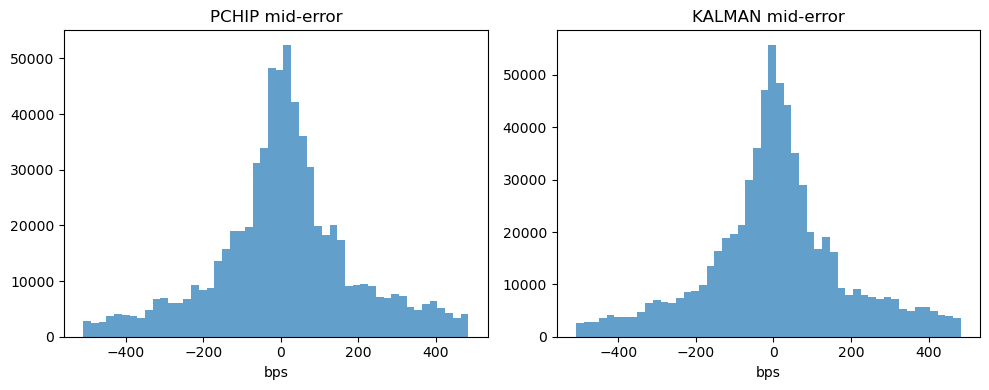

In [24]:
plt.figure(figsize=(10, 4))
for idx, (name, res) in enumerate(parity_results.items(), 1):
    print(res['parity'].columns)
    if res['parity'].is_empty():
        continue
    plt.subplot(1, len(parity_results), idx)
    plt.hist(res['parity']['error_mid_bps'], bins=50, alpha=0.7)
    plt.title(f"{name.upper()} mid-error")
    plt.xlabel("bps")
plt.tight_layout()
plt.show()


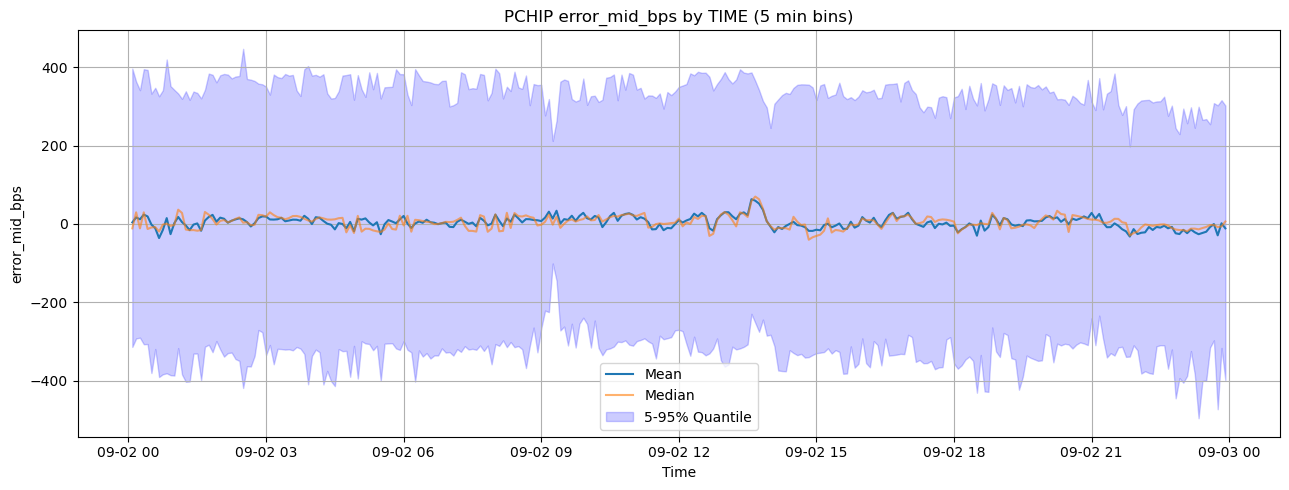

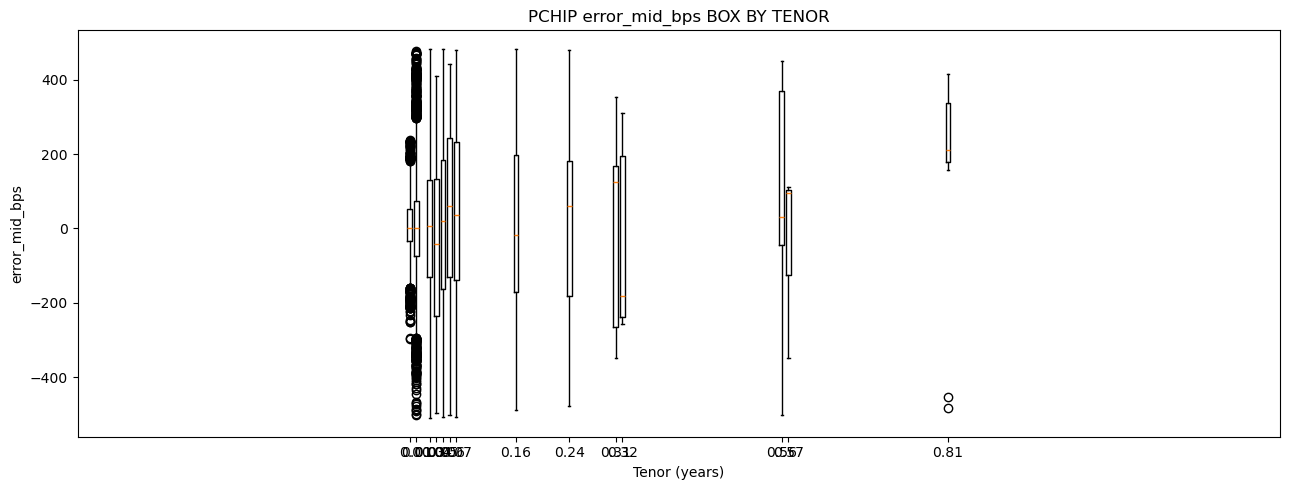

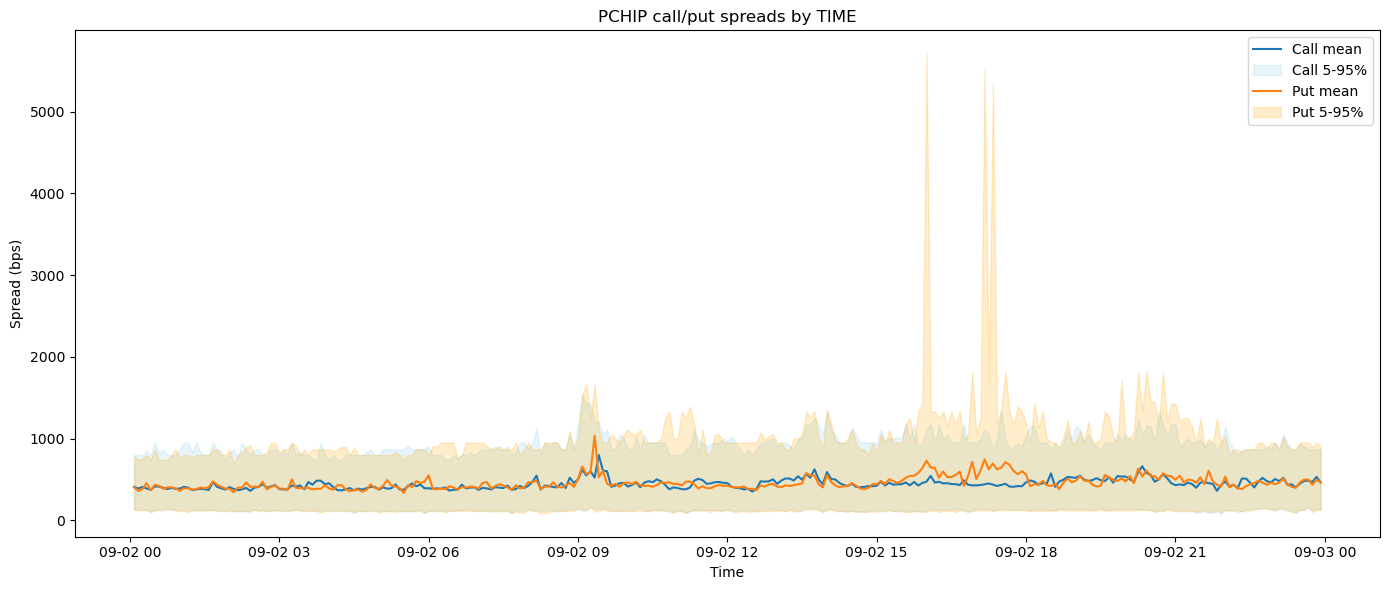

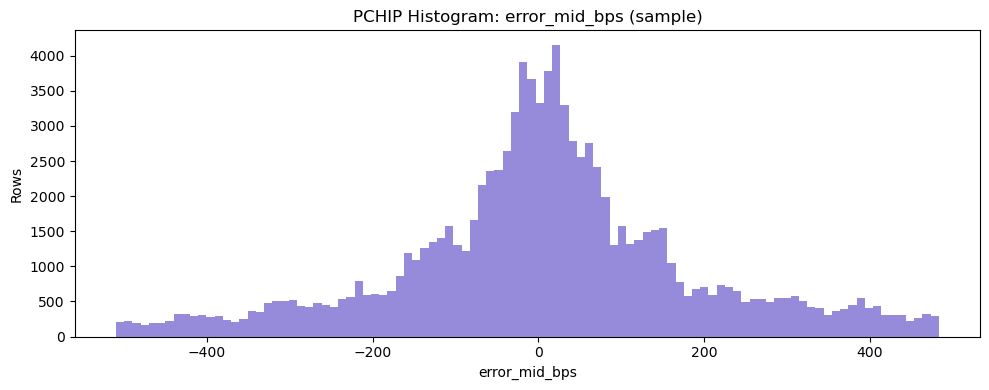


PCHIP Top 10 |error_mid_bps| rows:


,timeMs,expiry_dt,strike,T,moneyness,call_bid_1_px,call_ask_1_px,F_bid,F_ask,put_bid_1_px,put_ask_1_px,F_mid,F_implied_bid,F_implied_ask,F_implied_mid,error_bid_bps,error_ask_bps,error_mid_bps,call_spread_bps,put_spread_bps
0,1756817060471,1757664000000,104000,0.026856,0.950031,6.556178,61.737345,109466.338102,109473.903994,10.380616,10.926964,109470.121048,103995.629215,104051.356729,104023.492972,-512.682159,-508.016092,-510.348773,16160.000000,512.820513
1,1756817065091,1757664000000,104000,0.026856,0.950037,6.556131,61.736898,109465.664862,109473.208325,10.380540,10.926885,109469.436593,103995.629246,104051.356357,104023.492802,-512.620654,-507.952581,-510.286265,16160.000000,512.820513
2,1756817067181,1757664000000,104000,0.026856,0.950040,6.556109,61.190355,109465.363687,109472.897117,10.380507,10.926849,109469.130402,103995.629260,104050.809848,104023.219554,-512.593139,-507.976676,-510.284562,16129.032258,512.820513
3,1756817060841,1757664000000,104000,0.026856,0.950031,6.556174,63.922700,109466.283802,109473.847885,10.380609,10.926957,109470.065843,103995.629217,104053.542091,104024.585654,-512.677199,-507.800942,-510.238689,16279.069767,512.820513
4,1756817070831,1757664000000,104000,0.026856,0.950044,6.556073,61.736351,109464.842713,109472.358786,10.380448,10.926788,109468.600749,103995.629285,104051.355903,104023.492594,-512.545544,-507.875022,-510.209930,16160.000000,512.820513
5,1756817074262,1757664000000,104000,0.026856,0.950048,6.556039,61.189693,109464.358737,109471.858688,10.380394,10.926731,109468.108712,103995.629308,104050.809299,104023.219303,-512.501329,-507.881871,-510.191254,16129.032258,512.820513
6,1756817077031,1757664000000,104000,0.026856,0.950052,6.556011,61.735773,109463.972155,109471.459227,10.380351,10.926686,109467.715691,103995.629326,104051.355422,104023.492374,-512.466012,-507.792896,-510.129101,16160.000000,512.820513
7,1756817077321,1757664000000,104000,0.026856,0.950052,6.556008,61.735746,109463.931873,109471.417604,10.380347,10.926681,109467.674739,103995.629328,104051.355400,104023.492364,-512.462331,-507.789096,-510.125361,16160.000000,512.820513
8,1756817080774,1757664000000,104000,0.026856,0.950056,6.555975,62.828092,109463.455225,109470.925077,10.380294,10.926625,109467.190151,103995.629350,104052.447799,104024.038574,-512.418785,-507.639118,-510.028585,16220.472441,512.820513
9,1756817085681,1757664000000,104000,0.026855,0.950062,6.555928,61.734986,109462.787227,109470.234827,10.380219,10.926546,109466.511027,103995.629382,104051.354767,104023.492074,-512.357757,-507.681111,-510.019081,16160.000000,512.820513


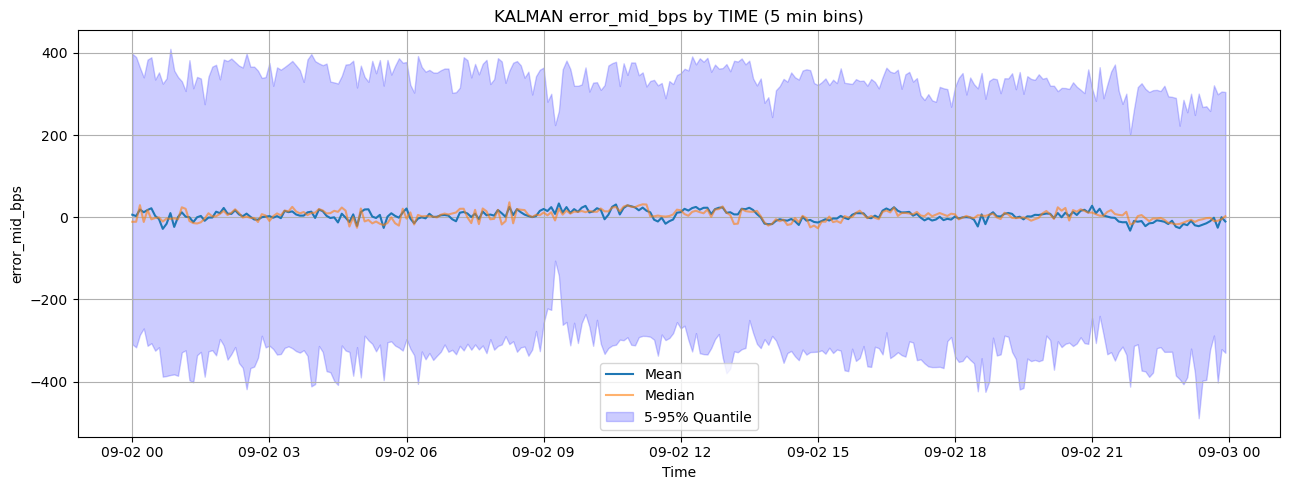

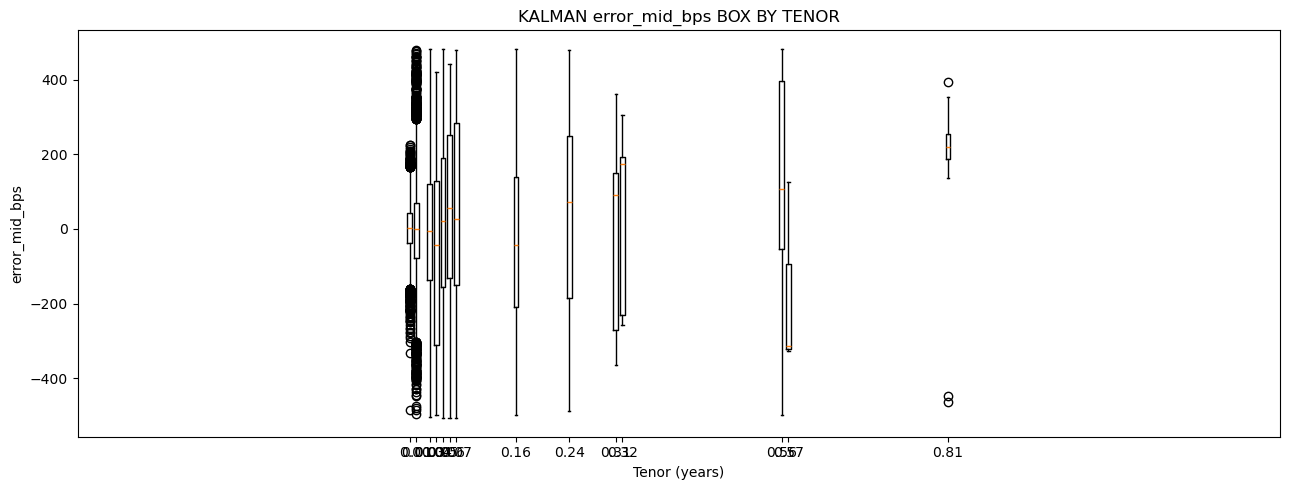

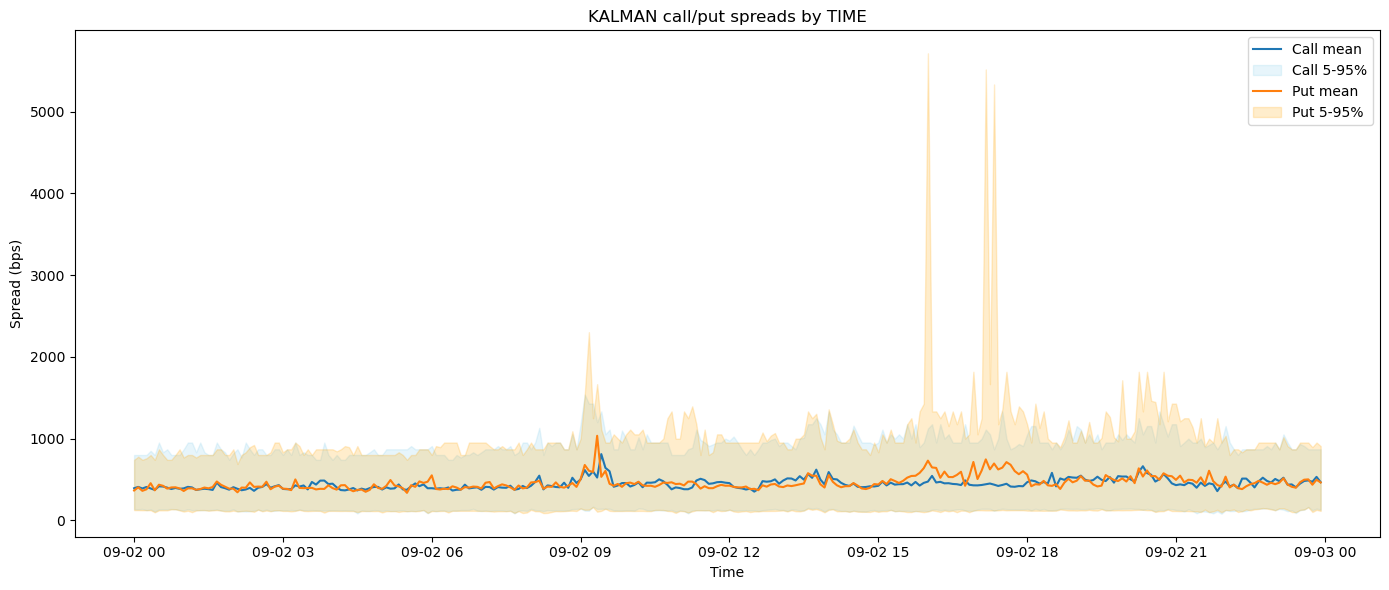

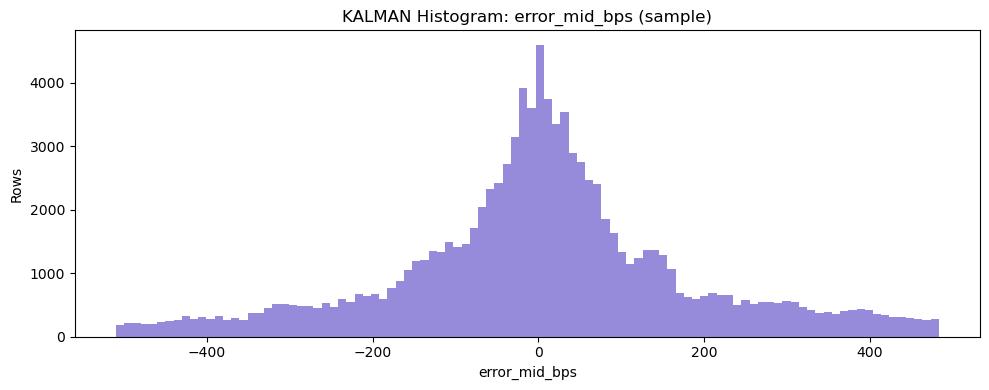


KALMAN Top 10 |error_mid_bps| rows:


,timeMs,expiry_dt,strike,T,moneyness,call_bid_1_px,call_ask_1_px,F_bid,F_ask,put_bid_1_px,put_ask_1_px,F_mid,F_implied_bid,F_implied_ask,F_implied_mid,error_bid_bps,error_ask_bps,error_mid_bps,call_spread_bps,put_spread_bps
0,1756841298110,1757059200000,105000,0.006910,0.950006,6.628449,58.551300,110525.542608,110525.642655,1.325690,1.436164,110525.592632,105005.192285,105057.225610,105031.208947,-512.368498,-507.423468,-509.895676,15932.203390,800.000000
1,1756841302568,1757059200000,105000,0.006909,0.950006,6.628449,58.551300,110525.541525,110525.641571,1.325690,1.436164,110525.591548,105005.192285,105057.225610,105031.208947,-512.368400,-507.423370,-509.895578,15932.203390,800.000000
2,1756841332578,1757059200000,105000,0.006909,0.950006,6.628449,58.551300,110525.534427,110525.634473,1.325690,1.436164,110525.584450,105005.192285,105057.225610,105031.208947,-512.367758,-507.422727,-509.894936,15932.203390,800.000000
3,1756841532769,1757059200000,105000,0.006902,0.950036,6.628227,57.996986,110522.075572,110522.175619,1.436116,1.546586,110522.125595,105005.081641,105056.560870,105030.821256,-512.065344,-507.173051,-509.618897,15897.435897,740.740741
4,1756819518128,1757664000000,104000,0.026778,0.950096,6.555933,66.105658,109462.571935,109462.672116,9.287572,9.833900,109462.622025,103996.722034,104056.818086,104026.770060,-512.233023,-506.465195,-509.348692,16390.977444,571.428571
5,1756838482557,1757059200000,105000,0.006999,0.950191,6.627075,57.434650,110504.086735,110504.186783,1.325415,1.435866,110504.136759,105005.191209,105056.109235,105030.650222,-510.427153,-505.588286,-508.007426,15862.068966,800.000000
6,1756838493766,1757059200000,105000,0.006999,0.950191,6.627075,57.434650,110504.077595,110504.177642,1.325415,1.435866,110504.127619,105005.191209,105056.109235,105030.650222,-510.426326,-505.587459,-508.006598,15862.068966,800.000000
7,1756837038257,1757059200000,105000,0.007045,0.950193,6.627009,57.434078,110503.844312,110503.944361,1.325402,1.435852,110503.894336,105005.191157,105056.108676,105030.649917,-510.405220,-505.566401,-507.985517,15862.068966,800.000000
8,1756837072288,1757059200000,105000,0.007044,0.950193,6.627009,57.986329,110503.836286,110503.936335,1.435852,1.546302,110503.886310,105005.080707,105056.550477,105030.815592,-510.415012,-505.523621,-507.969016,15897.435897,740.740741
9,1756779481428,1782460800000,110000,0.814349,0.950001,195.426562,199.247751,115789.302400,115789.408456,140.292252,143.021674,115789.355428,110052.404888,110058.955499,110055.680194,-508.155205,-507.569155,-507.862176,193.637621,192.678227


In [ ]:
for idx, (name, res) in enumerate(parity_results.items(), 1):
    df = res['parity']
    if df.is_empty():
        print(f"{name.upper()}: parity DataFrame is empty.")
        continue

    # Try a simpler approach: bin by time only and show error_mid_bps quantiles over time
    BIN_MINS = 5
    time_bin_col = (pl.col('timeMs') // (60_000 * BIN_MINS) * (60_000 * BIN_MINS)).cast(pl.Int64).alias('time_bin')
    df_bin = (
        df.with_columns([time_bin_col])
        .group_by(['time_bin'])
        .agg([
            pl.mean('error_mid_bps').alias('mean_error_mid_bps'),
            pl.std('error_mid_bps').alias('std_error_mid_bps'),
            pl.quantile('error_mid_bps', 0.05).alias('q05_error_mid_bps'),
            pl.median('error_mid_bps').alias('median_error_mid_bps'),
            pl.quantile('error_mid_bps', 0.95).alias('q95_error_mid_bps'),
            pl.len().alias('count'),
        ])
        .sort(['time_bin'])
        .to_pandas()
    )

    if df_bin.empty:
        print(f"{name.upper()}: Binned DataFrame is empty, skipping plot.")
    else:
        # Convert ms to datetime
        df_bin['datetime'] = pd.to_datetime(df_bin['time_bin'], unit='ms')

        fig, ax = plt.subplots(figsize=(13, 5))
        ax.plot(df_bin['datetime'], df_bin['mean_error_mid_bps'], label='Mean')
        ax.plot(df_bin['datetime'], df_bin['median_error_mid_bps'], label='Median', alpha=0.6)
        ax.fill_between(
            df_bin['datetime'],
            df_bin['q05_error_mid_bps'],
            df_bin['q95_error_mid_bps'],
            color='blue', alpha=0.2, label='5-95% Quantile'
        )
        ax.set_title(f"{name.upper()} error_mid_bps by TIME ({BIN_MINS} min bins)")
        ax.set_xlabel("Time")
        ax.set_ylabel("error_mid_bps")
        ax.legend()
        ax.grid(True)
        plt.tight_layout()
        plt.show()
    
    # Distribution snapshot: error_mid_bps by tenor (boxplot)
    # Polars DataFrame.sample() does not accept 'frac', use 'n' instead.
    n_rows = len(df)
    sample_size = max(1, int(n_rows * 0.02))
    sampled = (
        df.select(['T', 'error_mid_bps'])
        .sample(n=sample_size)
        .to_pandas()
    )
    # Bin tenor for grouping (e.g., to nearest 0.01)
    sampled['tenor_bin'] = (sampled['T'] * 100).round().astype(int) / 100
    plt.figure(figsize=(13, 5))
    # Use groupby to get the groups and their data, avoid .items() on pandas.SeriesGroupBy
    ten_bins = list(sampled.groupby('tenor_bin')['error_mid_bps'])
    box_data = [g.values for _, g in ten_bins]
    bin_positions = [b for b, _ in ten_bins]
    plt.boxplot(box_data, positions=bin_positions, widths=0.007)
    plt.title(f"{name.upper()} error_mid_bps BOX BY TENOR")
    plt.xlabel("Tenor (years)")
    plt.ylabel("error_mid_bps")
    plt.tight_layout()
    plt.show()

    # Call spread and put spread by time (mean, quantiles)
    spread_bin = (
        df.with_columns([
            (pl.col('timeMs') // (60_000 * BIN_MINS) * (60_000 * BIN_MINS)).cast(pl.Int64).alias('time_bin'),
        ])
        .group_by(['time_bin'])
        .agg([
            pl.mean('call_spread_bps').alias('mean_call_spread_bps'),
            pl.quantile('call_spread_bps', 0.05).alias('call_spread_p5'),
            pl.quantile('call_spread_bps', 0.95).alias('call_spread_p95'),
            pl.mean('put_spread_bps').alias('mean_put_spread_bps'),
            pl.quantile('put_spread_bps', 0.05).alias('put_spread_p5'),
            pl.quantile('put_spread_bps', 0.95).alias('put_spread_p95'),
        ])
        .sort(['time_bin'])
        .to_pandas()
    )
    spread_bin['datetime'] = pd.to_datetime(spread_bin['time_bin'], unit='ms')

    plt.figure(figsize=(14, 6))
    plt.plot(spread_bin['datetime'], spread_bin['mean_call_spread_bps'], label='Call mean')
    plt.fill_between(
        spread_bin['datetime'],
        spread_bin['call_spread_p5'],
        spread_bin['call_spread_p95'],
        color='skyblue', alpha=0.2, label='Call 5-95%')
    plt.plot(spread_bin['datetime'], spread_bin['mean_put_spread_bps'], label='Put mean')
    plt.fill_between(
        spread_bin['datetime'],
        spread_bin['put_spread_p5'],
        spread_bin['put_spread_p95'],
        color='orange', alpha=0.2, label='Put 5-95%')
    plt.title(f"{name.upper()} call/put spreads by TIME")
    plt.xlabel("Time")
    plt.ylabel("Spread (bps)")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Histogram: overall error_mid_bps (sampled)
    hist_sample_size = min(100_000, len(df))
    sampled = df.sample(n=hist_sample_size).to_pandas()
    plt.figure(figsize=(10, 4))
    plt.hist(sampled['error_mid_bps'], bins=100, color='slateblue', alpha=0.7)
    plt.title(f"{name.upper()} Histogram: error_mid_bps (sample)")
    plt.xlabel("error_mid_bps")
    plt.ylabel("Rows")
    plt.tight_layout()
    plt.show()

    # Show a summary of the worst diffs
    df_sorted = df.sort(pl.col('error_mid_bps').abs(), descending=True).head(10).to_pandas()
    print(f"\n{name.upper()} Top 10 |error_mid_bps| rows:")
    display(df_sorted)



PCHIP moneyness 0.950–0.975 :: lower bounds passed: 0 / 57644
PCHIP moneyness 0.950–0.975 :: upper bounds passed: 57644 / 57644
PCHIP moneyness 0.950–0.975 :: both bounds passed: 0 / 57644


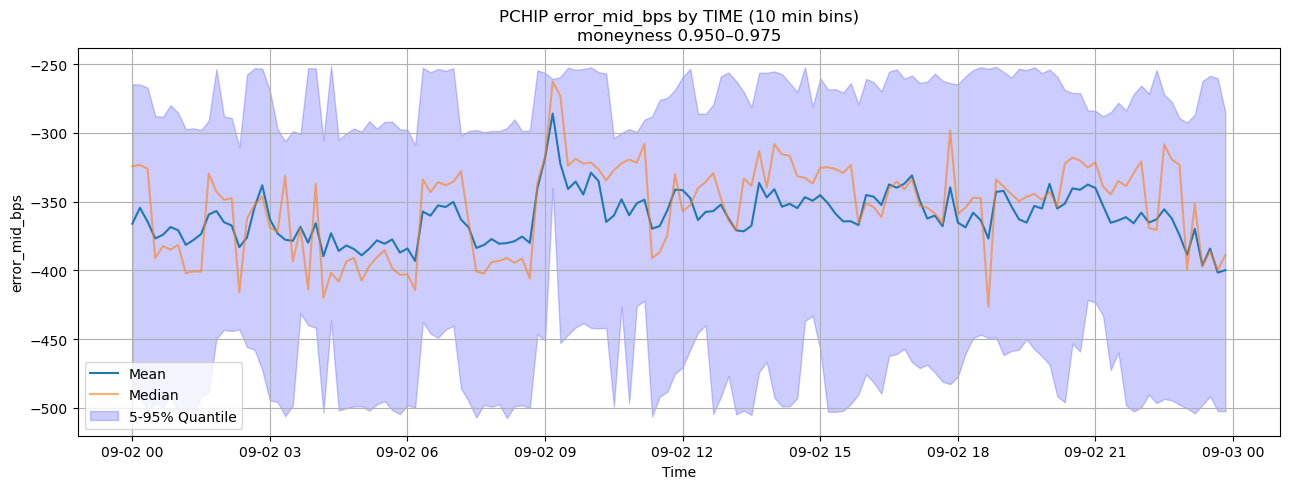

PCHIP moneyness 0.975–1.000 :: lower bounds passed: 355 / 268464
PCHIP moneyness 0.975–1.000 :: upper bounds passed: 268255 / 268464
PCHIP moneyness 0.975–1.000 :: both bounds passed: 146 / 268464


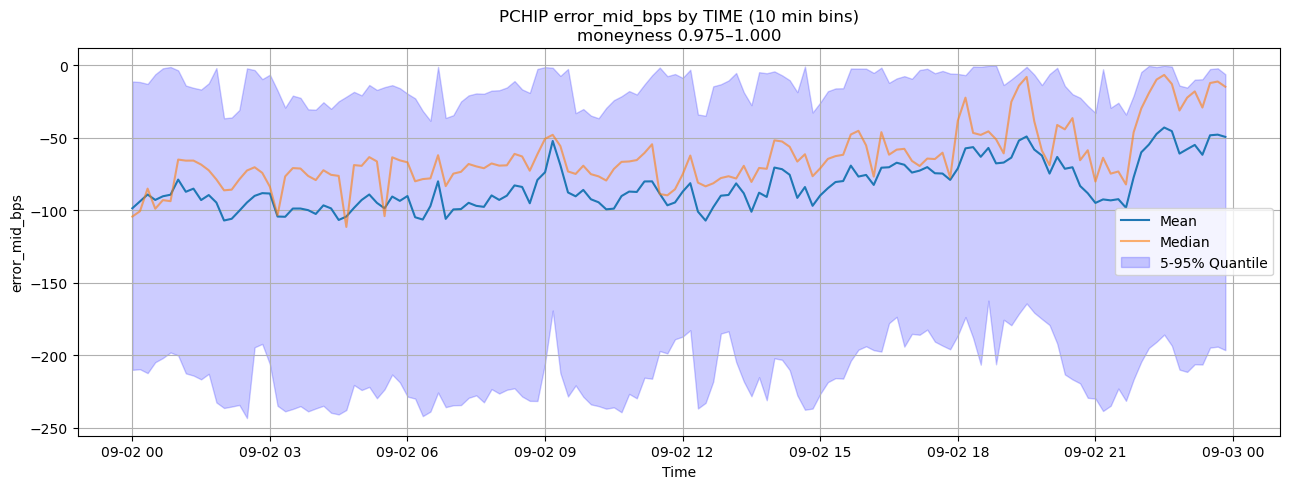

PCHIP moneyness 1.000–1.025 :: lower bounds passed: 286180 / 286228
PCHIP moneyness 1.000–1.025 :: upper bounds passed: 109 / 286228
PCHIP moneyness 1.000–1.025 :: both bounds passed: 61 / 286228


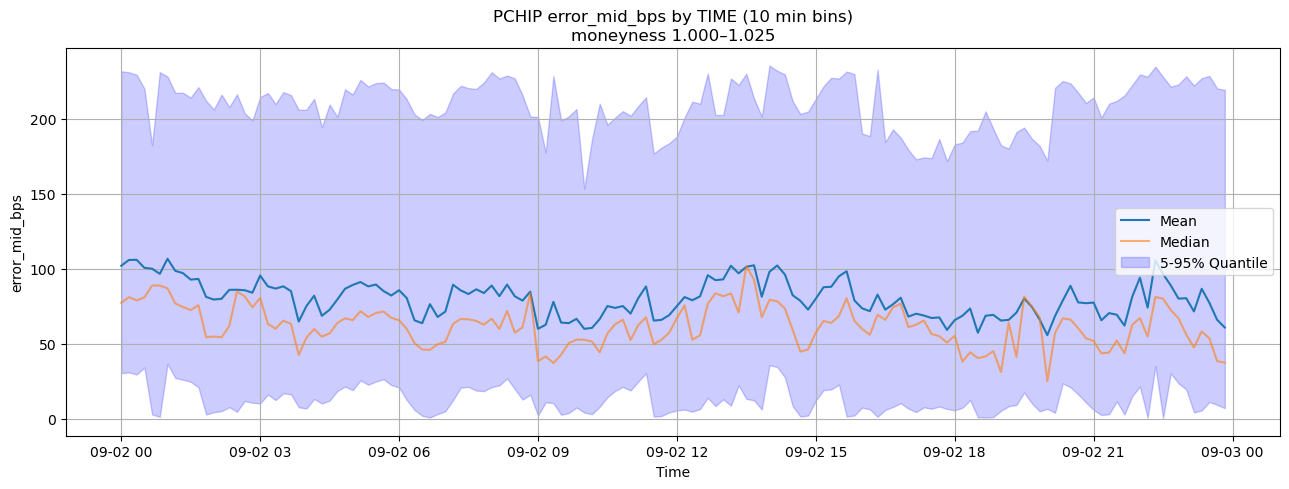

PCHIP moneyness 1.025–1.050 :: lower bounds passed: 68444 / 68444
PCHIP moneyness 1.025–1.050 :: upper bounds passed: 0 / 68444
PCHIP moneyness 1.025–1.050 :: both bounds passed: 0 / 68444


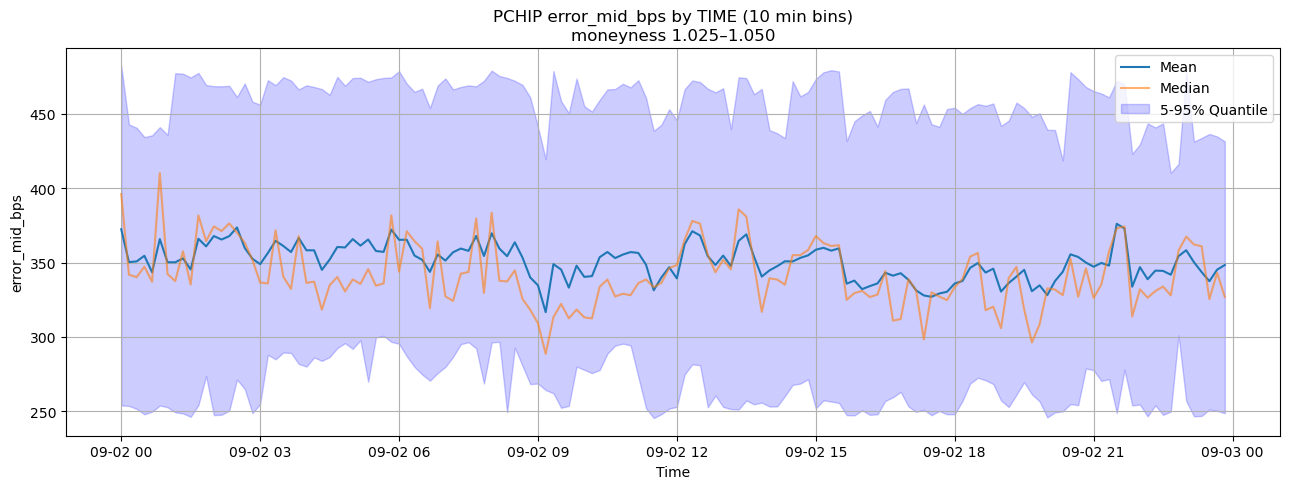

KALMAN moneyness 0.950–0.975 :: lower bounds passed: 0 / 59046
KALMAN moneyness 0.950–0.975 :: upper bounds passed: 59046 / 59046
KALMAN moneyness 0.950–0.975 :: both bounds passed: 0 / 59046


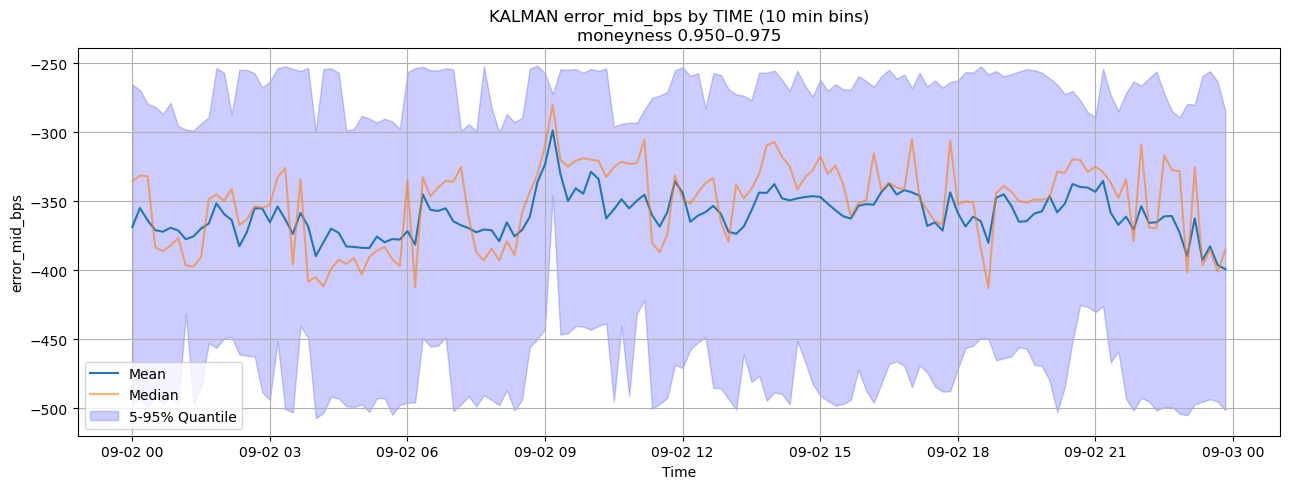

KALMAN moneyness 0.975–1.000 :: lower bounds passed: 200 / 271214
KALMAN moneyness 0.975–1.000 :: upper bounds passed: 271211 / 271214
KALMAN moneyness 0.975–1.000 :: both bounds passed: 197 / 271214


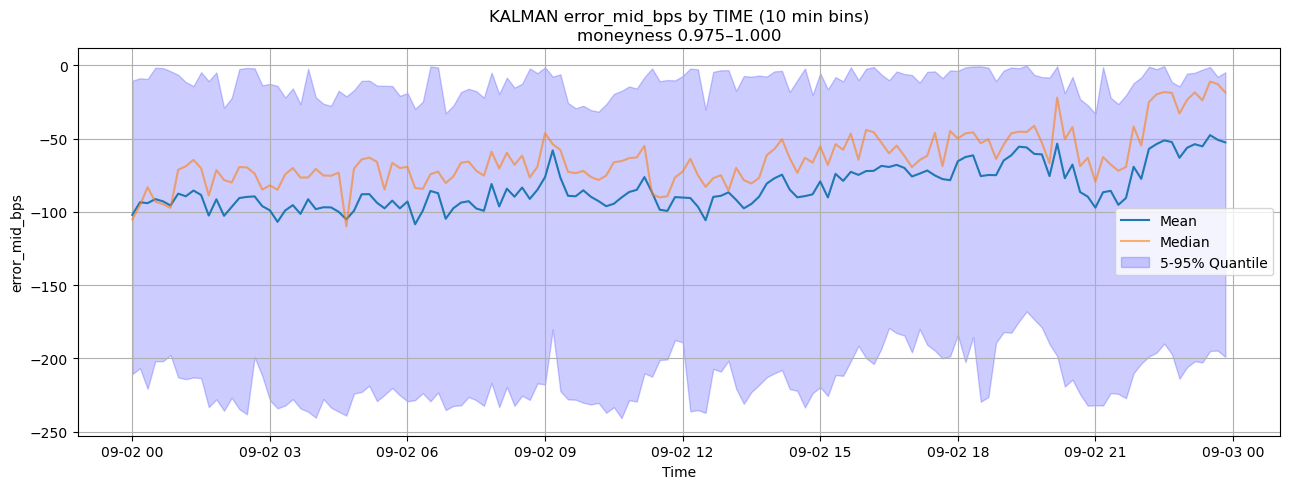

KALMAN moneyness 1.000–1.025 :: lower bounds passed: 284329 / 284330
KALMAN moneyness 1.000–1.025 :: upper bounds passed: 122 / 284330
KALMAN moneyness 1.000–1.025 :: both bounds passed: 121 / 284330


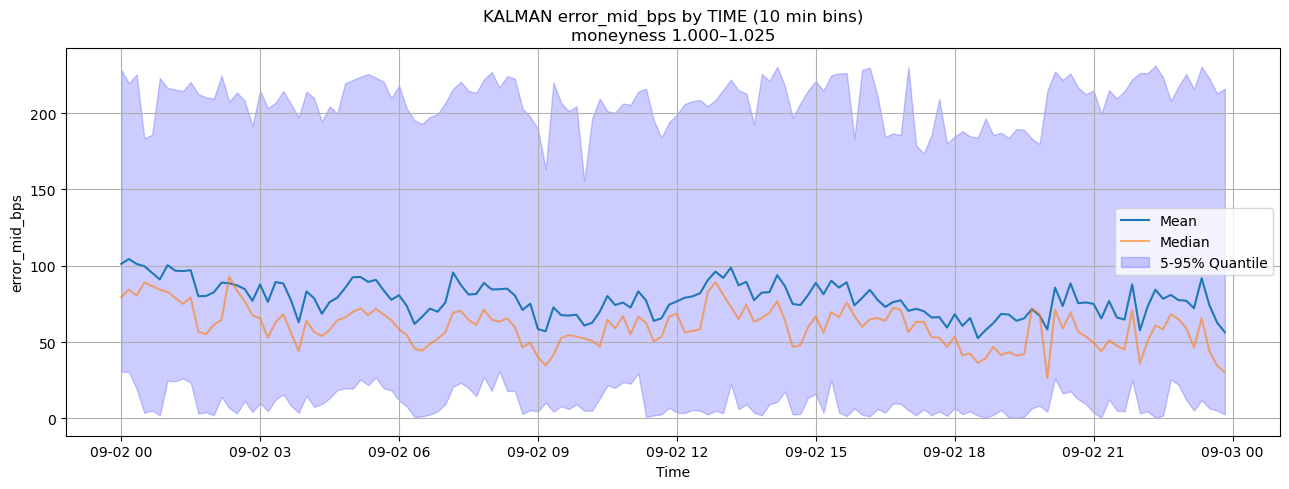

KALMAN moneyness 1.025–1.050 :: lower bounds passed: 68058 / 68058
KALMAN moneyness 1.025–1.050 :: upper bounds passed: 0 / 68058
KALMAN moneyness 1.025–1.050 :: both bounds passed: 0 / 68058


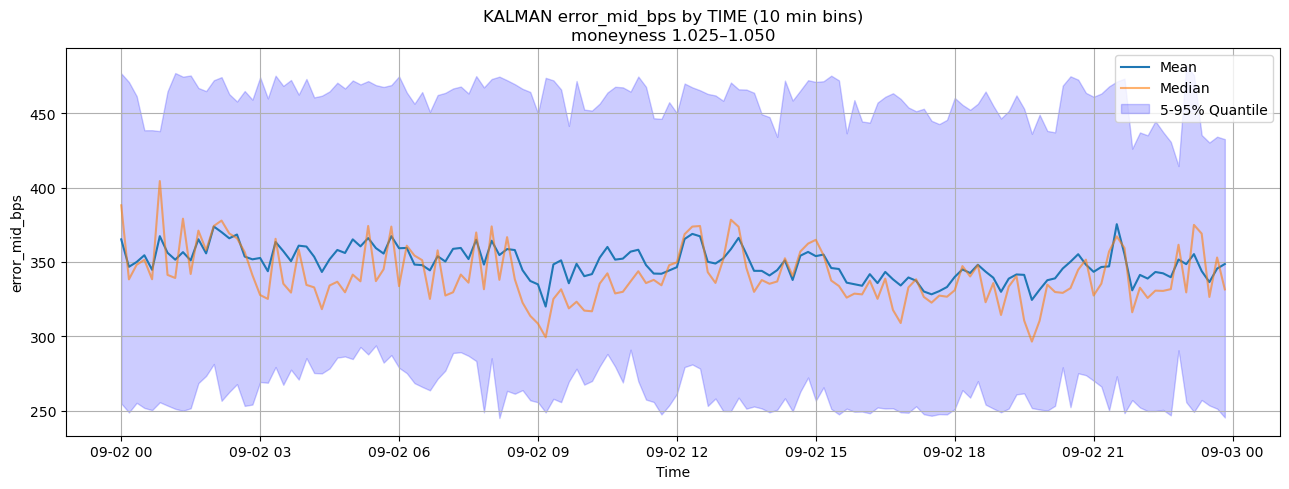

In [30]:
for idx, (name, res) in enumerate(parity_results.items(), 1):
    df = res['parity']
    if df.is_empty():
        print(f"{name.upper()}: parity DataFrame is empty.")
        continue

    # Try a simpler approach: bin by time only and show error_mid_bps quantiles over time
    BIN_MINS = 10
    time_bin_col = (pl.col('timeMs') // (60_000 * BIN_MINS) * (60_000 * BIN_MINS)).cast(pl.Int64).alias('time_bin')
    # Iterate over moneyness ranges and plot for each
    moneyness_ranges = [
        (0.95, 0.975), 
        (0.975, 1.0), 
        (1.0, 1.025), 
        (1.025, 1.05)
    ]
    for mn_lo, mn_hi in moneyness_ranges:
        msk = (pl.col('moneyness') >= mn_lo) & (pl.col('moneyness') < mn_hi)
        df_slice = df.filter(msk)
        label = f"moneyness {mn_lo:.3f}–{mn_hi:.3f}"
        lower_bounds_passed = df_slice.filter(pl.col('F_mid') < pl.col('F_implied_ask')).height
        upper_bounds_passed = df_slice.filter(pl.col('F_implied_bid') < pl.col('F_mid')).height
        both_bounds_passed = df_slice.filter((pl.col('F_implied_bid') < pl.col('F_mid')) & (pl.col('F_mid') < pl.col('F_implied_ask'))).height
        print(f"{name.upper()} {label} :: lower bounds passed: {lower_bounds_passed} / {len(df_slice)}")
        print(f"{name.upper()} {label} :: upper bounds passed: {upper_bounds_passed} / {len(df_slice)}")
        print(f"{name.upper()} {label} :: both bounds passed: {both_bounds_passed} / {len(df_slice)}")

        df_bin = (
            df_slice.with_columns([time_bin_col])
            .group_by(['time_bin'])
            .agg([
                pl.mean('error_mid_bps').alias('mean_error_mid_bps'),
                pl.std('error_mid_bps').alias('std_error_mid_bps'),
                pl.quantile('error_mid_bps', 0.05).alias('q05_error_mid_bps'),
                pl.median('error_mid_bps').alias('median_error_mid_bps'),
                pl.quantile('error_mid_bps', 0.95).alias('q95_error_mid_bps'),
                pl.len().alias('count'),
            ])
            .sort(['time_bin'])
            .to_pandas()
        )
        if df_bin.empty:
            print(f"{name.upper()}: Binned DataFrame empty for {label}, skipping plot.")
            continue
        # Convert ms to datetime
        df_bin['datetime'] = pd.to_datetime(df_bin['time_bin'], unit='ms')
        fig, ax = plt.subplots(figsize=(13, 5))
        ax.plot(df_bin['datetime'], df_bin['mean_error_mid_bps'], label='Mean')
        ax.plot(df_bin['datetime'], df_bin['median_error_mid_bps'], label='Median', alpha=0.6)
        ax.fill_between(
            df_bin['datetime'],
            df_bin['q05_error_mid_bps'],
            df_bin['q95_error_mid_bps'],
            color='blue', alpha=0.2, label='5-95% Quantile'
        )
        ax.set_title(f"{name.upper()} error_mid_bps by TIME ({BIN_MINS} min bins)\n{label}")
        ax.set_xlabel("Time")
        ax.set_ylabel("error_mid_bps")
        ax.legend()
        ax.grid(True)
        plt.tight_layout()
        plt.show()

## Pillar-Level Diagnostics

In [8]:
for name, df in pillar_results.items():
    if df.is_empty():
        continue
    metrics = evaluate_curve_snapshot(
        df['T'].to_numpy(),
        df['obs_bid'].to_numpy(),
        df['obs_ask'].to_numpy(),
        df['model_bid'].to_numpy(),
        df['model_ask'].to_numpy(),
    )
    print(f"Avg WMAE (aggregate snapshot) :: {name.upper()}")
    display(metrics)


Avg WMAE (aggregate snapshot) :: PCHIP


metric_name,value,mae_bps,max_error_bps,n_pillars,side
str,f64,f64,f64,i64,str
"""wmae_pillar_fit""",5.495474,5.495474,52.878446,11512,"""bid"""
"""wmae_pillar_fit""",5.489588,5.489588,52.878397,11512,"""ask"""
"""wmae_pillar_fit""",5.489512,5.489512,52.878422,11512,"""mid"""


Avg WMAE (aggregate snapshot) :: KALMAN


metric_name,value,mae_bps,max_error_bps,n_pillars,side
str,f64,f64,f64,i64,str
"""wmae_pillar_fit""",2.02994,2.02994,15.129273,11512,"""bid"""
"""wmae_pillar_fit""",1.864903,1.864903,8.507674,11512,"""ask"""
"""wmae_pillar_fit""",1.929299,1.929299,9.218248,11512,"""mid"""


### Bid/Ask Anomalies

In [12]:
for name, df in pillar_results.items():
    mismatches = find_model_mismatches(df)
    if mismatches.is_empty():
        print(f"{name.upper()}: model spreads always overlap market spreads")
    else:
        print(f"{name.upper()}: {len(mismatches)} pillar rows with disjoint spreads")
        display(mismatches.head())


## LOEO Results

In [ ]:
loeo_summary_rows = []
for name, df in loeo_results.items():
    if df.is_empty():
        continue
    row = df.filter(pl.col('success')).select([
        pl.lit(name).alias('recipe'),
        pl.mean('error_mid_bps').alias('mean_error_mid_bps'),
        pl.col('error_mid_bps').max().alias('max_error_mid_bps'),
    ])
    loeo_summary_rows.append(row)

if loeo_summary_rows:
    display(pl.concat(loeo_summary_rows))
else:
    print("No LOEO output available.")


### LOEO Error Distribution (Example)

In [ ]:
plt.figure(figsize=(10, 4))
for idx, (name, df) in enumerate(loeo_results.items(), 1):
    if df.is_empty():
        continue
    plt.subplot(1, len(loeo_results), idx)
    plt.hist(df.filter(pl.col('success'))['error_mid_bps'], bins=50, alpha=0.7)
    plt.title(f"{name.upper()} LOEO")
    plt.xlabel("mid error (bps)")
plt.tight_layout()
plt.show()


---
Adjust the parameters (dates, binning, moneyness window) or add new recipes to
extend this evaluation pipeline.